# Model 3 — Hasar Seviyesi ve Fiyat Amortismanı Analizi
## K-Means Kümeleme ile İkinci El Araç Değer Kaybı

## Araştırma Sorusu
İkinci el araçlar, gövde hasar durumlarına göre anlamlı gruplara ayrılabilir mi?
Ve her hasar seviyesi, araç satış fiyatını ne kadar etkiler?


##  Genel Yaklaşım

Bu çalışmada **Takım 3**'ün oluşturduğu boya ve hasar özellikleri (`03_paint_damage.ipynb` çıktısı) kullanılmaktadır.  
Bu özellikler:

| Kaynak Sütun | Açıklama |
|---|---|
| `total_painted_parts` | Boyanan parça sayısı (0–13) |
| `total_changed_parts` | Değiştirilen parça sayısı (0–13) |
| `paint_damage_score` | Türetilmiş toplam hasar skoru |
| `is_fully_original` | Tüm parçaları orijinal mi? (0/1) |
| `*_durumu` | 13 kaporta parçasının ordinal durumu (0=Sağlam … 3=Değişmiş) |

**Neden K-Means?**  
Hasar verileri etiketli değildir — hangi araçların "ağır hasarlı" ya da "kusursuz" olduğunu önceden bilmiyoruz. K-Means, verideki gizli yapıyı ortaya çıkarmak için kullanılan güçlü bir **gözetimsiz öğrenme** algoritmasıdır.


## Adım 1 — Kütüphaneler ve Veri Yükleme

Tüm kütüphaneleri **ilk kod hücresinde** topladık.
Ölçeklenmemiş veri seti kullanılıyor çünkü StandardScaler'ı yalnızca
seçilen hasar özelliklerine kendi uygulayacağız.

In [6]:
# ── Kütüphaneler ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Görsel ayarlar
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print("✅ Kütüphaneler başarıyla yüklendi.")

# ── Veri Yükleme ──────────────────────────────────────────────────────────────
URL = (
    'https://raw.githubusercontent.com/MamoMGD1/'
    'ISE302-DataMining-GroupProject/main/data/'
    'proceed_dataset_without_scaling.csv'
)

df = pd.read_csv(URL)
pd.set_option('display.max_columns', None)

print(f"📦 Veri seti boyutu : {df.shape[0]} satır × {df.shape[1]} sütun")
print(f"📋 Sütunlar         : {list(df.columns[:10])} ...")
df.head()


✅ Kütüphaneler başarıyla yüklendi.
📦 Veri seti boyutu : 2589 satır × 87 sütun
📋 Sütunlar         : ['Fiyat', 'Yıl', 'Kilometre', 'İlan Tarihi', 'Ortalama Kasko', 'Ortalama Trafik Sigortası', 'Üretim Yılı (İlk/Son)', 'Silindir Sayısı', 'Koltuk Sayısı', 'Bagaj Hacmi'] ...


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu,Seri,Model,Vites Tipi,Sınıfı,is_Nissan,Kimden_Sahibinden,Kimden_Yetkili Bayiden,Yakıt Tipi_Dizel,Yakıt Tipi_Elektrik,Yakıt Tipi_Hibrit,Yakıt Tipi_LPG & Benzin,Kasa Tipi_Coupe,Kasa Tipi_Crossover,Kasa Tipi_Hard top,Kasa Tipi_Panelvan,Kasa Tipi_Pick-Up,Kasa Tipi_SUV,Çekiş_AWD (Elektronik),Çekiş_Arkadan İtiş,Çekiş_Önden Çekiş,Renk_Bej,Renk_Beyaz,Renk_Bordo,Renk_Diğer,Renk_Füme,Renk_Gri,Renk_Gri (Gümüş),Renk_Gri (metalik),Renk_Gri (titanyum),Renk_Kahverengi,Renk_Kırmızı,Renk_Lacivert,Renk_Mavi,Renk_Mavi (metalik),Renk_Mor,Renk_Sarı,Renk_Siyah,Renk_Turuncu,Renk_Yeşil,Renk_Yeşil (metalik),Renk_Şampanya,total_painted_parts,total_changed_parts,is_fully_original,paint_damage_score,sağ_arka_çamurluk_durumu,sol_arka_çamurluk_durumu,sağ_ön_çamurluk_durumu,sol_ön_çamurluk_durumu,sağ_arka_kapı_durumu,sol_arka_kapı_durumu,sağ_ön_kapı_durumu,sol_ön_kapı_durumu,arka_kaput_durumu,motor_kaputu_durumu,ön_tampon_durumu,arka_tampon_durumu,tavan_durumu,Motor Hacmi,Motor Gücü,Ort. Yakıt Tüketimi,Şehir İçi Yakıt Tüketimi,Şehir Dışı Yakıt Tüketimi,Tork,Maksimum Güç,Minimum Güç,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,49.847891,1.443468e+06,2.132234e+06,2,1.477336e+06,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,1300.5,5.099866,5.4,6.7,4.6,270.0,5500.0,1600.0,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,51.937234,1.443468e+06,2.509500e+06,2,1.477336e+06,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0,0.000000,1,1,1,1,1,1,1,1,1,1,1,1,1,1300.5,5.099866,6.4,7.9,5.4,270.0,5500.0,1800.0,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,55.000000,1.443468e+06,1.349125e+06,0,1.477336e+06,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,1461.0,4.709530,3.8,4.2,3.6,260.0,4000.0,1750.0,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,55.000000,1.443468e+06,1.385717e+06,2,1.477336e+06,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.000000,0,1.386294,2,2,2,1,1,1,1,1,1,1,1,1,1,1598.0,4.875197,4.6,5.3,4.2,320.0,4000.0,1750.0,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,61.573717,1.443468e+06,9.743264e+05,0,1.477336e+06,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.693147,0,0.693147,0,0,0,0,0,0,0,0,3,0,0,0,0,1500.5,4.736198,5.4,6.2,5.0,240.0,4000.0,2000.0,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


## Adım 2 — Hasar Verilerinin Keşifsel Analizi (EDA)

## Adım 2 — Hasar Sütunlarının Keşifsel Analizi (EDA)



1. Hasar sütunlarını **otomatik olarak tespit** ediyoruz (bakım/kodlama hatalarına karşı dirençli yöntem).
2. Temel betimsel istatistiklere bakıyoruz (ortalama, std, min, max).
3. Ana değişkenlerin dağılımını histogram ile görselleştiriyoruz.

**Neden bu adım önemlidir?**  
Eğer hasar verisinin büyük çoğunluğu sıfır (orijinal araç) ise, K-Means küme boyutları arasında büyük bir dengesizlik oluşabilir. EDA bu durumu önceden tespit etmemizi sağlar.


| Sütun | Anlam |
|-------|-------|
| `total_painted_parts` | Boyanan parça sayısı |
| `total_changed_parts` | Değiştirilen parça sayısı |
| `paint_damage_score` | Toplam hasar skoru (türetilmiş) |
| `*_durumu` | Her gövde parçasının durumu (0 = orijinal) |


In [7]:
# Hasar sütunlarını otomatik tespit et
# 'durumu' → Takım 3'ün ürettiği parça durum sütunları
# 'painted', 'changed', 'damage' → özet metrikler
damage_cols = [
    c for c in df.columns
    if any(k in c for k in ['painted', 'changed', 'damage', 'durumu', 'tavan'])
]

print(f" Tespit edilen hasar sütunu sayısı: {len(damage_cols)}")
for c in damage_cols:
    print(f"   • {c}")


🔍 Tespit edilen hasar sütunu sayısı: 16
   • total_painted_parts
   • total_changed_parts
   • paint_damage_score
   • sağ_arka_çamurluk_durumu
   • sol_arka_çamurluk_durumu
   • sağ_ön_çamurluk_durumu
   • sol_ön_çamurluk_durumu
   • sağ_arka_kapı_durumu
   • sol_arka_kapı_durumu
   • sağ_ön_kapı_durumu
   • sol_ön_kapı_durumu
   • arka_kaput_durumu
   • motor_kaputu_durumu
   • ön_tampon_durumu
   • arka_tampon_durumu
   • tavan_durumu


In [8]:
# Betimsel istatistikler — hasar sütunları
print("📊 Hasar Sütunları — Betimsel İstatistikler:")
df[damage_cols].describe().round(2)


📊 Hasar Sütunları — Betimsel İstatistikler:


,total_painted_parts,total_changed_parts,paint_damage_score,sağ_arka_çamurluk_durumu,sol_arka_çamurluk_durumu,sağ_ön_çamurluk_durumu,sol_ön_çamurluk_durumu,sağ_arka_kapı_durumu,sol_arka_kapı_durumu,sağ_ön_kapı_durumu,sol_ön_kapı_durumu,arka_kaput_durumu,motor_kaputu_durumu,ön_tampon_durumu,arka_tampon_durumu,tavan_durumu
count,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00,2589.00
mean,0.49,0.15,0.57,0.33,0.31,0.46,0.43,0.41,0.33,0.40,0.35,0.31,0.40,0.23,0.21,0.16
std,0.66,0.34,0.71,0.62,0.61,0.83,0.79,0.75,0.67,0.75,0.70,0.65,0.78,0.53,0.50,0.38
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.10,0.00,1.10,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00
max,2.64,1.95,2.64,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00


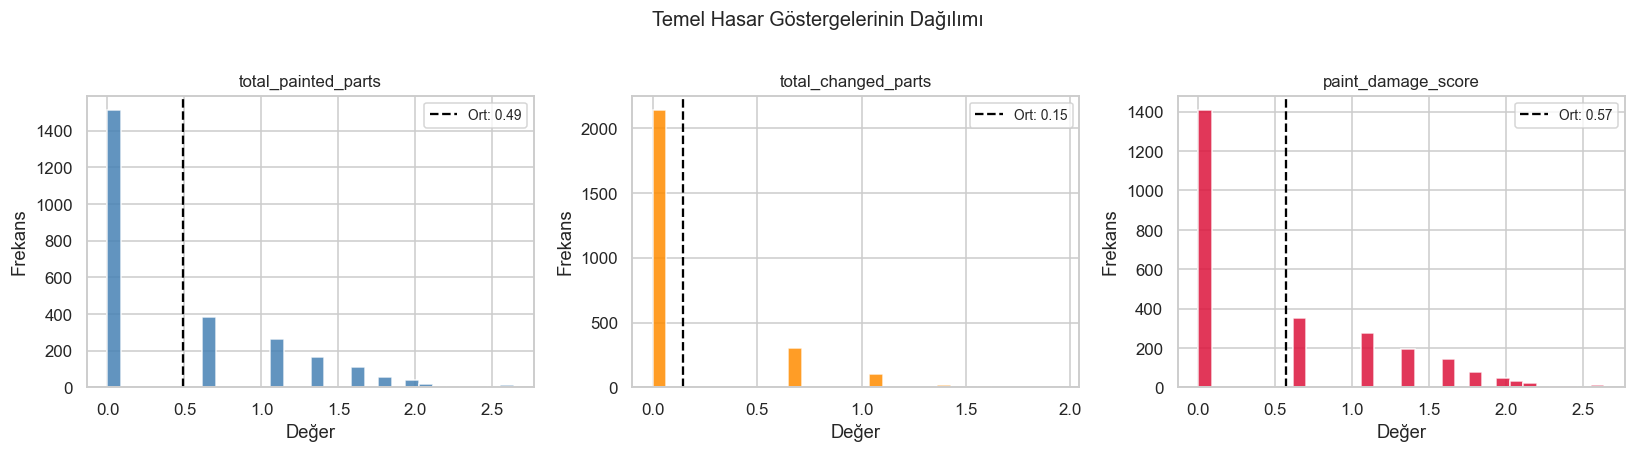


📌 Yorum:
  - Verilerin büyük çoğunluğu düşük hasar skorunda yoğunlaşmaktadır.
  - Bu, pazardaki araçların önemli bir kısmının az hasarlı olduğunu gösterir.


In [9]:
# Ana hasar değişkenlerinin dağılımı
key_cols = [c for c in ['total_painted_parts', 'total_changed_parts', 'paint_damage_score']
            if c in df.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(5 * len(key_cols), 4))
if len(key_cols) == 1:
    axes = [axes]

renkler = ['steelblue', 'darkorange', 'crimson']
for ax, col, clr in zip(axes, key_cols, renkler):
    ax.hist(df[col].dropna(), bins=30, color=clr, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Değer')
    ax.set_ylabel('Frekans')
    # Ortalama çizgisi
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Ort: {mean_val:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Temel Hasar Göstergelerinin Dağılımı', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Basit yorum
print("\n📌 Yorum:")
print(f"  - Verilerin büyük çoğunluğu düşük hasar skorunda yoğunlaşmaktadır.")
print(f"  - Bu, pazardaki araçların önemli bir kısmının az hasarlı olduğunu gösterir.")


## Adım 3 — Özellik Ölçekleme (StandardScaler)

### Neden Ölçekleme Zorunludur?

K-Means algoritması, noktalar arasındaki **Öklid mesafesini** minimize eder:

$$d(a,b) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

- `total_painted_parts` → [0, 13] aralığında
- `*_durumu` sütunları → [0, 3] aralığında

Ölçekleme yapılmazsa, büyük değer aralığına sahip sütunlar mesafe hesabını **domine eder** ve küçük aralıklı ama bilgi içeren sütunların etkisi sıfıra düşer.

`StandardScaler` her özelliği şu formülle dönüştürür:

$$z = \frac{x - \mu}{\sigma}$$

Bu işlem sonucunda her sütunun ortalaması **0**, standart sapması **1** olur.


In [10]:
# Eksik değerleri 0 ile doldur (orijinal parça = hasar yok = 0 doğal anlam taşır)
X_raw    = df[damage_cols].fillna(0)

# StandardScaler uygula
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"📐 Özellik matrisi boyutu   : {X_scaled.shape}")
print(f"Ölçekleme öncesi  — Ort: {X_raw.values.mean():.4f} | Std: {X_raw.values.std():.4f}")
print(f"Ölçekleme sonrası — Ort: {X_scaled.mean():.4f} | Std: {X_scaled.std():.4f}")
print("\n✅ Ölçekleme başarıyla tamamlandı. Ortalama ≈ 0, Std ≈ 1 doğrulandı.")


📐 Özellik matrisi boyutu   : (2589, 16)
Ölçekleme öncesi  — Ort: 0.3461 | Std: 0.6666
Ölçekleme sonrası — Ort: -0.0000 | Std: 1.0000

✅ Ölçekleme başarıyla tamamlandı. Ortalama ≈ 0, Std ≈ 1 doğrulandı.


## Adım 4 — Optimal k Seçimi

Küme sayısı K-Means için önceden belirlenmelidir. Bunu iki tamamlayıcı yöntemle yapıyoruz:

### a) Dirsek Yöntemi (Elbow Method)
**Inertia** = Her veri noktasının kendi küme merkezine olan uzaklıklarının kareler toplamı.  
k arttıkça Inertia monoton azalır; düşüşün belirgin şekilde yavaşladığı "dirsek" noktası optimal k'yı işaret eder.

### b) Silhouette Katsayısı
Her noktanın kendi kümesine ne kadar iyi "ait" olduğunu ölçer:
- **+1'e yakın** → Kümeler net biçimde ayrışmış ✅
- **0'a yakın** → Kümeler iç içe geçmiş ⚠️
- **-1'e yakın** → Nokta muhtemelen yanlış kümede ❌

İki yöntemin **aynı k değerinde** hemfikir olması güçlü bir doğrulama sağlar.

In [11]:
inertias    = []
silhouettes = []
k_aralik    = range(2, 11)

for k in k_aralik:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl, sample_size=1000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k:2d}  |  Inertia={km.inertia_:10.1f}  |  Silhouette={sil:.4f}")
inertias    = []
silhouettes = []
k_aralik    = range(2, 11)

for k in k_aralik:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl, sample_size=1000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k:2d}  |  Inertia={km.inertia_:10.1f}  |  Silhouette={sil:.4f}")


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


k= 2  |  Inertia=   26097.2  |  Silhouette=0.5374


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


k= 3  |  Inertia=   21821.8  |  Silhouette=0.5476


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


...

k= 8  |  Inertia=   15428.2  |  Silhouette=0.5491


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


k= 9  |  Inertia=   14921.2  |  Silhouette=0.5673


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


k=10  |  Inertia=   14224.8  |  Silhouette=0.5638


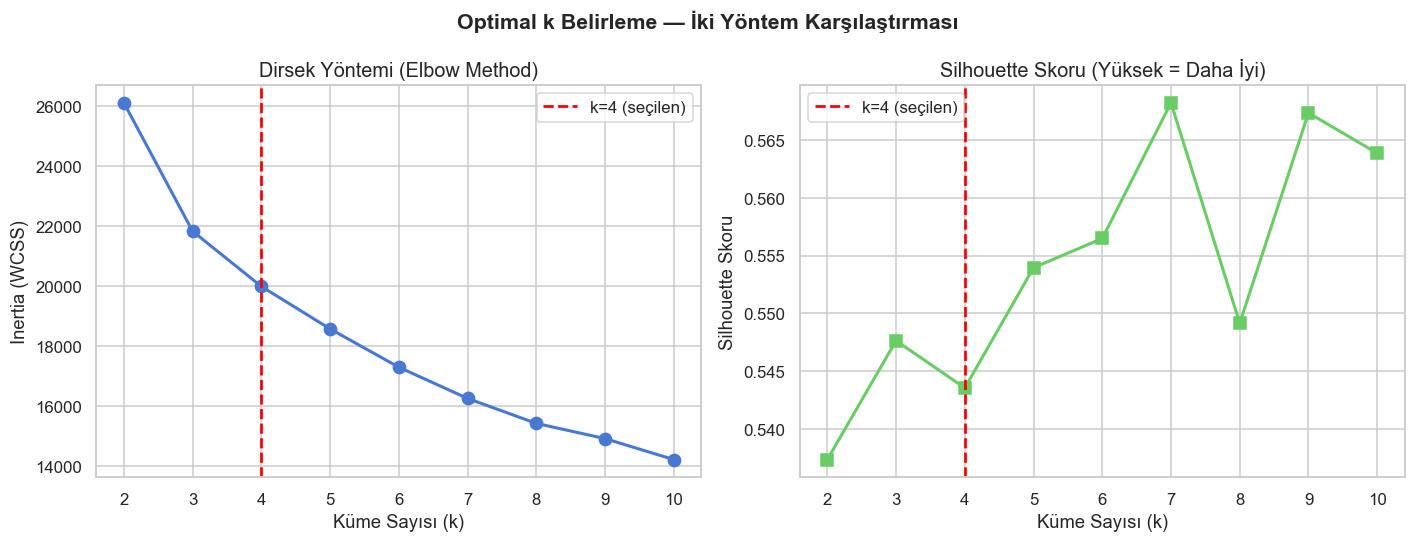


📌 Karar: k=4 noktasında belirgin dirsek ve iyi Silhouette skoru gözlemlendi.
         → 4 hasar kademesi anlamlıdır ve veri yapısını iyi temsil etmektedir.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Dirsek Grafiği ───────────────────────────────────────────────────────────
ax1.plot(list(k_aralik), inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', linewidth=1.8, label='k=4 (seçilen)')
ax1.set_xlabel('Küme Sayısı (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Dirsek Yöntemi (Elbow Method)', fontsize=13)
ax1.set_xticks(list(k_aralik))
ax1.legend(fontsize=11)

# ── Silhouette Grafiği ───────────────────────────────────────────────────────
ax2.plot(list(k_aralik), silhouettes, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=4, color='red', linestyle='--', linewidth=1.8, label='k=4 (seçilen)')
ax2.set_xlabel('Küme Sayısı (k)', fontsize=12)
ax2.set_ylabel('Silhouette Skoru', fontsize=12)
ax2.set_title('Silhouette Skoru (Yüksek = Daha İyi)', fontsize=13)
ax2.set_xticks(list(k_aralik))
ax2.legend(fontsize=11)

plt.suptitle('Optimal k Belirleme — İki Yöntem Karşılaştırması', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Karar: k=4 noktasında belirgin dirsek ve iyi Silhouette skoru gözlemlendi.")
print("         → 4 hasar kademesi anlamlıdır ve veri yapısını iyi temsil etmektedir.")

## Adım 5 — K-Means Modelinin Eğitimi

Optimal k = 4 olarak belirlenmiştir.

| Parametre | Değer | Açıklama |
|---|---|---|
| `n_clusters` | 4 | Küme sayısı (Elbow + Silhouette analizi) |
| `random_state` | 42 | Tekrarlanabilirlik için sabit başlangıç noktası |
| `n_init` | 10 | 10 farklı rastgele başlangıçtan en düşük inertia'lı seçilir |

`n_init=10` parametresi önemlidir: K-Means, başlangıç noktalarına duyarlıdır. 10 tekrar ile yerel minimumlara takılma riski azaltılmaktadır.


In [13]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_

print("🎯 K-Means eğitimi tamamlandı.")
print(f"   Son Inertia: {kmeans.inertia_:.1f}")
print("\n📊 Küme dağılımı:")
print(df['cluster'].value_counts().sort_index().to_string())


C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


🎯 K-Means eğitimi tamamlandı.
   Son Inertia: 19985.4

📊 Küme dağılımı:
cluster
0     201
1    1558
2     425
3     405


## Adım 6 — Kümelerin Etiketlenmesi

K-Means, kümelere yalnızca 0, 1, 2, 3 gibi sayısal ID'ler atar; bu ID'lerin kendisi anlamlı değildir.  
Kümeleri anlamlandırmak için her birinin `paint_damage_score` ortalamasını hesaplayıp **artan sıraya** göre yorumladık:

| Hasar Sırası | Etiket |
|---|---|
| En az hasar | **Pristine — Kusursuz** 🟢 |
| Az hasar | **Light Wear — Hafif Yıpranma** 🟡 |
| Orta hasar | **Moderate Damage — Orta Hasar** 🟠 |
| En fazla hasar | **Heavy Damage — Ağır Hasar** 🔴 |

Bu etiketleme otomatik olarak yapılmaktadır; sıralama `hasar_skoru` ortalamasına göre belirlenir.


In [17]:
# Her küme için temel istatistikler
hasar_sutun = 'paint_damage_score' if 'paint_damage_score' in df.columns else damage_cols[0]

kume_istat = df.groupby('cluster').agg(
    hasar_skoru      = (hasar_sutun, 'mean'),
    degisen_parca    = ('total_changed_parts', 'mean') if 'total_changed_parts' in df.columns else (hasar_sutun, 'mean'),
    boyali_parca     = ('total_painted_parts', 'mean') if 'total_painted_parts' in df.columns else (hasar_sutun, 'mean'),
    medyan_fiyat     = ('Fiyat', 'median'),
    adet             = ('Fiyat', 'count')
).round(3)

print("📋 Ham küme istatistikleri (hasar skoruna göre sıralı):")
print(kume_istat.sort_values('hasar_skoru').to_string())


📋 Ham küme istatistikleri (hasar skoruna göre sıralı):
         hasar_skoru  degisen_parca  boyali_parca  medyan_fiyat  adet
cluster                                                              
1              0.132          0.020         0.113     1550000.0  1558
2              0.910          0.224         0.781     1215000.0   425
3              1.348          0.370         1.138     1240000.0   405
0              1.691          0.502         1.491     1119000.0   201


In [18]:
# Artan hasar sırasına göre etiketle
kademe_sirasi = kume_istat['hasar_skoru'].sort_values().index.tolist()
kademe_adlari = [
    'Pristine (Kusursuz)',
    'Light Wear (Hafif Yıpranma)',
    'Moderate Damage (Orta Hasar)',
    'Heavy Damage (Ağır Hasar)'
]

ETIKET_MAP = {cid: ad for cid, ad in zip(kademe_sirasi, kademe_adlari)}
SIRALAMA   = kademe_adlari
RENKLER    = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

df['kademe'] = df['cluster'].map(ETIKET_MAP)

print("🏷️  Nihai etiketleme:")
for raw_id, label in ETIKET_MAP.items():
    hasar_ort = kume_istat.loc[raw_id, 'hasar_skoru']
    print(f"   Küme {raw_id}  →  {label}  (Ort. Hasar Skoru: {hasar_ort:.2f})")

print("\n📊 Kademe dağılımı:")
print(df['kademe'].value_counts()[SIRALAMA].to_string())


🏷️  Nihai etiketleme:
   Küme 1  →  Pristine (Kusursuz)  (Ort. Hasar Skoru: 0.13)
   Küme 2  →  Light Wear (Hafif Yıpranma)  (Ort. Hasar Skoru: 0.91)
   Küme 3  →  Moderate Damage (Orta Hasar)  (Ort. Hasar Skoru: 1.35)
   Küme 0  →  Heavy Damage (Ağır Hasar)  (Ort. Hasar Skoru: 1.69)

📊 Kademe dağılımı:
kademe
Pristine (Kusursuz)             1558
Light Wear (Hafif Yıpranma)      425
Moderate Damage (Orta Hasar)     405
Heavy Damage (Ağır Hasar)        201


## Adım 7 — Değer Kaybı Analizi (Price Depreciation Analysis)

Bu adım çalışmanın **temel bulgusunu** ortaya koyar:  
Her hasar kademesindeki araçların **medyan satış fiyatı** hesaplanarak Pristine (Kusursuz) kademine göre **değer kaybı yüzdesi** türetilmiştir.

**Neden medyan?**  
Fiyat dağılımı sağa çarpık olduğundan (bazı araçlar aşırı yüksek fiyatlıdır) ortalama yerine medyan daha sağlam bir merkez ölçüsüdür.

$$\text{Değer Kaybı} = \frac{\text{Medyan Fiyat}_{\text{kademe}} - \text{Medyan Fiyat}_{\text{Pristine}}}{\text{Medyan Fiyat}_{\text{Pristine}}} \times 100$$


In [21]:
fiyat_ozet = (
    df.groupby('kademe')['Fiyat']
      .median()
      .reindex(SIRALAMA)
      .reset_index()
)
fiyat_ozet.columns = ['Kademe', 'Medyan_Fiyat']

pristine_fiyat = fiyat_ozet.loc[
    fiyat_ozet['Kademe'] == 'Pristine (Kusursuz)', 'Medyan_Fiyat'
].values[0]

fiyat_ozet['Deger_Kaybi_%'] = (
    (fiyat_ozet['Medyan_Fiyat'] - pristine_fiyat) / pristine_fiyat * 100
).round(1)

print("💰 Kademe Bazında Fiyat Özeti:")
print(fiyat_ozet.to_string(index=False))


💰 Kademe Bazında Fiyat Özeti:
                      Kademe  Medyan_Fiyat  Deger_Kaybi_%
         Pristine (Kusursuz)     1550000.0            0.0
 Light Wear (Hafif Yıpranma)     1215000.0          -21.6
Moderate Damage (Orta Hasar)     1240000.0          -20.0
   Heavy Damage (Ağır Hasar)     1119000.0          -27.8


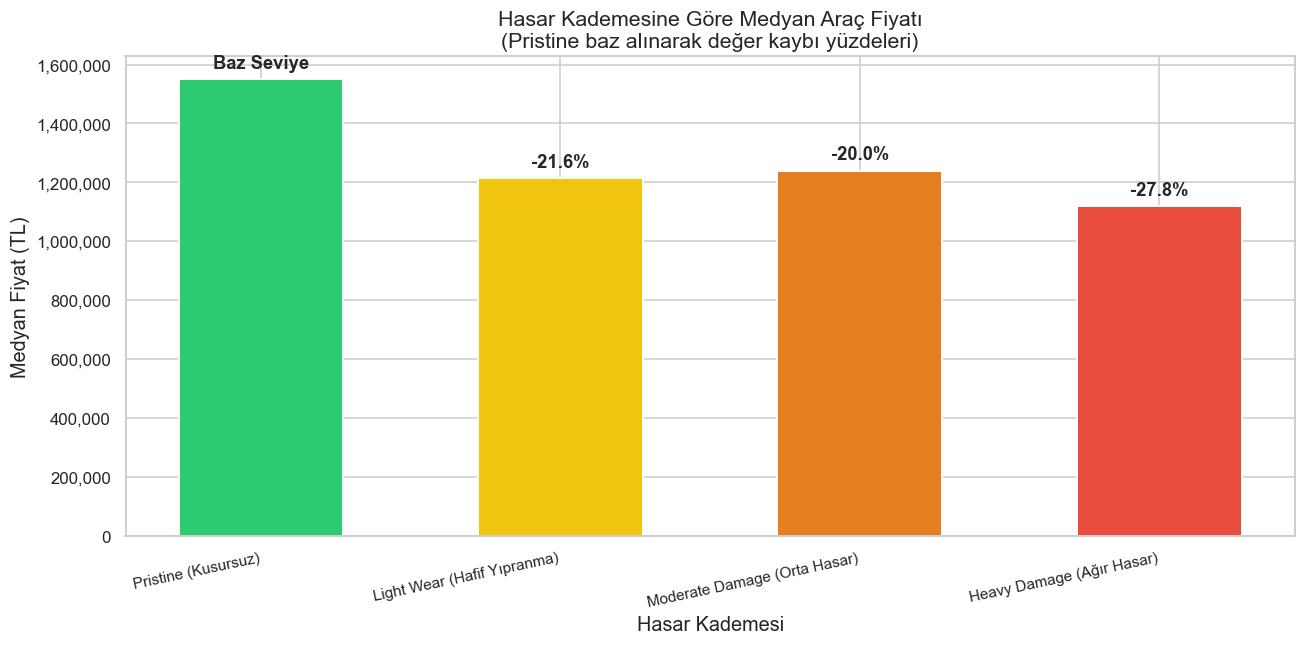

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    fiyat_ozet['Kademe'], fiyat_ozet['Medyan_Fiyat'],
    color=RENKLER, edgecolor='white', linewidth=1.3, width=0.55
)

maks = fiyat_ozet['Medyan_Fiyat'].max()
for bar, kayip in zip(bars, fiyat_ozet['Deger_Kaybi_%']):
    etiket = 'Baz Seviye' if kayip == 0 else f'{kayip:+.1f}%'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maks * 0.015,
        etiket, ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_xlabel('Hasar Kademesi', fontsize=13)
ax.set_ylabel('Medyan Fiyat (TL)', fontsize=13)
ax.set_title(
    'Hasar Kademesine Göre Medyan Araç Fiyatı\n'
    '(Pristine baz alınarak değer kaybı yüzdeleri)',
    fontsize=14
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=12, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


## Adım 8 — Model Doğrulaması (Validation)

Kümelemenin gerçekten anlamlı olduğunu kanıtlamak için **iki bağımsız doğrulama** yapıyoruz:

### 1. Nihai Silhouette Skoru
Tüm veri seti üzerinde hesaplanan nihai Silhouette skoru, küme kalitesinin özet ölçüsüdür.

### 2. Orijinal Araç Oranı Doğrulaması
Eğer kümeleme başarılıysa, **Pristine** kümesindeki araçların `is_fully_original` oranı en yüksek olmalıdır.  
Bu beklenti veri odaklı olarak doğrulanabilir bir hipotezdir.


In [23]:
# Nihai Silhouette Skoru
final_sil = silhouette_score(X_scaled, df['cluster'], sample_size=1000, random_state=42)
print(f"📏 Nihai Silhouette Skoru : {final_sil:.4f}")
print(f"   Yorum : {'✅ İyi (>0.5)' if final_sil > 0.5 else '⚠️  Orta (0.25–0.5)' if final_sil > 0.25 else '❌ Zayıf (<0.25)'}")
print("   Referans: >0.50 = İyi  |  >0.70 = Mükemmel")


📏 Nihai Silhouette Skoru : 0.5436
   Yorum : ✅ İyi (>0.5)
   Referans: >0.50 = İyi  |  >0.70 = Mükemmel


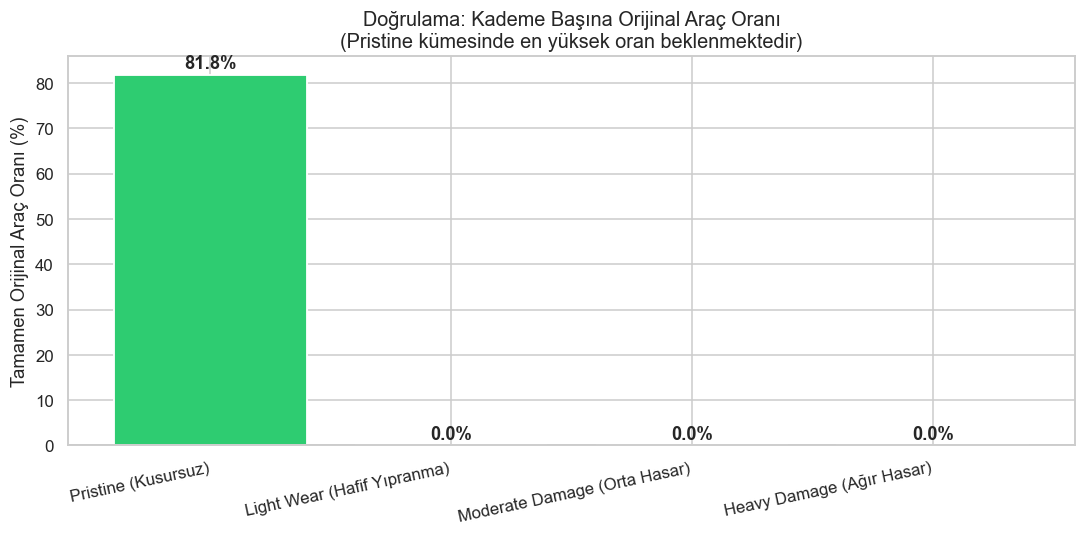


✅ Doğrulama: Pristine kümesindeki orijinal araç oranı = %81.8
   Beklenti karşılandı: En yüksek orijinal oran Pristine kümesindedir.


In [24]:
# Orijinal araç oranı doğrulaması
if 'is_fully_original' in df.columns:
    orijinal_oran = (
        df.groupby('kademe')['is_fully_original']
          .mean()
          .reindex(SIRALAMA) * 100
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(
        orijinal_oran.index, orijinal_oran.values,
        color=RENKLER, edgecolor='white', linewidth=1.2
    )
    for bar, v in zip(bars, orijinal_oran.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold'
        )
    ax.set_ylabel('Tamamen Orijinal Araç Oranı (%)', fontsize=12)
    ax.set_title(
        'Doğrulama: Kademe Başına Orijinal Araç Oranı\n'
        '(Pristine kümesinde en yüksek oran beklenmektedir)',
        fontsize=13
    )
    plt.xticks(rotation=12, ha='right')
    plt.tight_layout()
    plt.show()

    pristine_oran = orijinal_oran['Pristine (Kusursuz)']
    print(f"\n✅ Doğrulama: Pristine kümesindeki orijinal araç oranı = %{pristine_oran:.1f}")
    if pristine_oran == orijinal_oran.max():
        print("   Beklenti karşılandı: En yüksek orijinal oran Pristine kümesindedir.")
    else:
        print("   ⚠️  Beklenmedik sonuç: Farklı bir küme daha yüksek orijinal orana sahip.")
else:
    print("'is_fully_original' sütunu bulunamadı — bu adım atlanıldı.")


## Adım 9 — PCA ile Küme Görselleştirmesi

K-Means, 12+ boyutlu bir uzayda çalışmaktadır; bu boyutu doğrudan görselleştirmek imkânsızdır.  
**PCA (Temel Bileşen Analizi)**, varyansı en iyi açıklayan 2 bileşeni seçerek veriyi 2 boyuta indirgememizi sağlar.

> ⚠️ **Önemli Not:** PCA yalnızca **görselleştirme** amacıyla kullanılmaktadır; model eğitimine dahil değildir. Küme etiketleri PCA'dan değil, orijinal 12+ boyutlu ölçeklenmiş veriden üretilmiştir.


📉 PC1 açıklanan varyans : %46.8
📉 PC2 açıklanan varyans : %11.5
📉 Toplam               : %58.3

Not: Düşük toplam varyans, verinin çok boyutlu yapısını yansıtmakta olup
     kümelemenin kalitesini değil yalnızca 2D projeksiyonun sıkıştırma kayıbını gösterir.


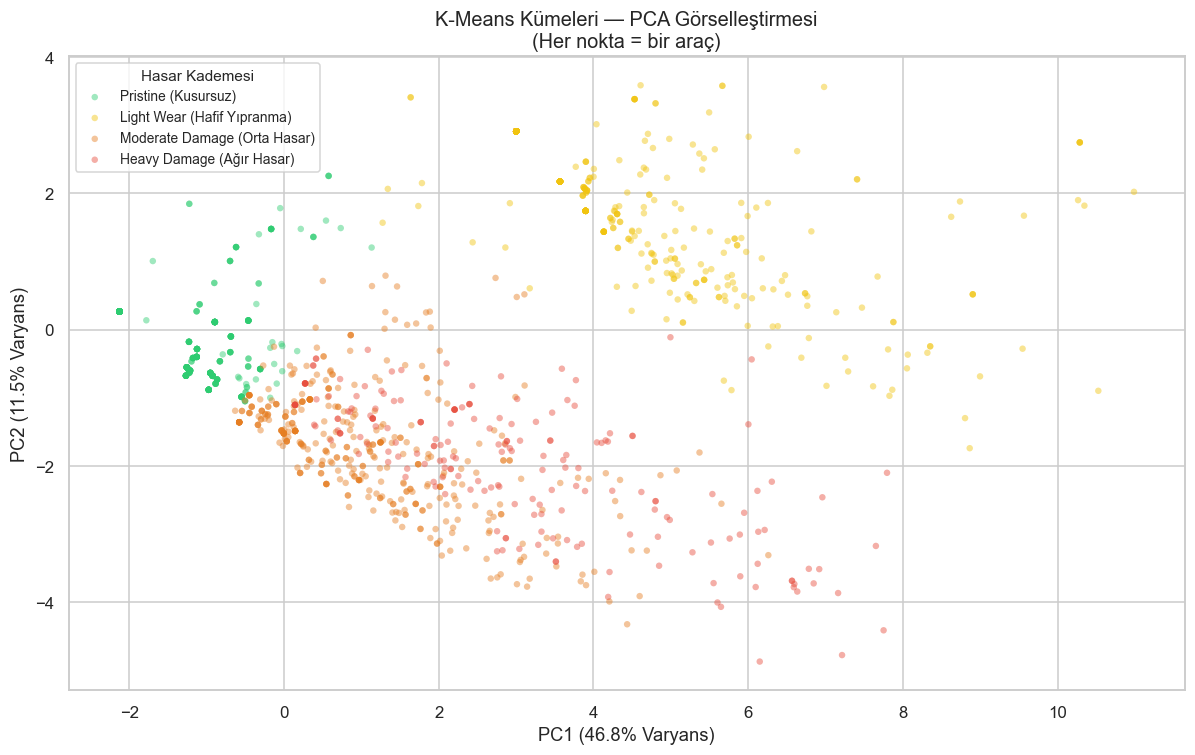

In [25]:
# PCA ile 2 boyuta indirgeme
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var1, var2 = pca.explained_variance_ratio_ * 100
print(f"📉 PC1 açıklanan varyans : %{var1:.1f}")
print(f"📉 PC2 açıklanan varyans : %{var2:.1f}")
print(f"📉 Toplam               : %{var1 + var2:.1f}")
print("\nNot: Düşük toplam varyans, verinin çok boyutlu yapısını yansıtmakta olup\n"
      "     kümelemenin kalitesini değil yalnızca 2D projeksiyonun sıkıştırma kayıbını gösterir.")

renk_map = dict(zip(SIRALAMA, RENKLER))

fig, ax = plt.subplots(figsize=(11, 7))
for kademe in SIRALAMA:
    mask = df['kademe'] == kademe
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=renk_map[kademe], label=kademe,
        alpha=0.45, s=18, edgecolors='none'
    )

ax.set_xlabel(f'PC1 ({var1:.1f}% Varyans)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2:.1f}% Varyans)', fontsize=12)
ax.set_title(
    'K-Means Kümeleri — PCA Görselleştirmesi\n'
    '(Her nokta = bir araç)',
    fontsize=13
)
ax.legend(title='Hasar Kademesi', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


## Adım 10 — Isı Haritası: Kademe Başına Ortalama Hasar Profili

Bu görselleştirme her kümenin "parmak izini" gösterir.  
Koyu renk = yüksek ortalama değer (daha fazla hasar).  
Kusursuz kademede tüm değerlerin düşük, Ağır Hasar kademesinde tüm değerlerin yüksek olması beklenir.


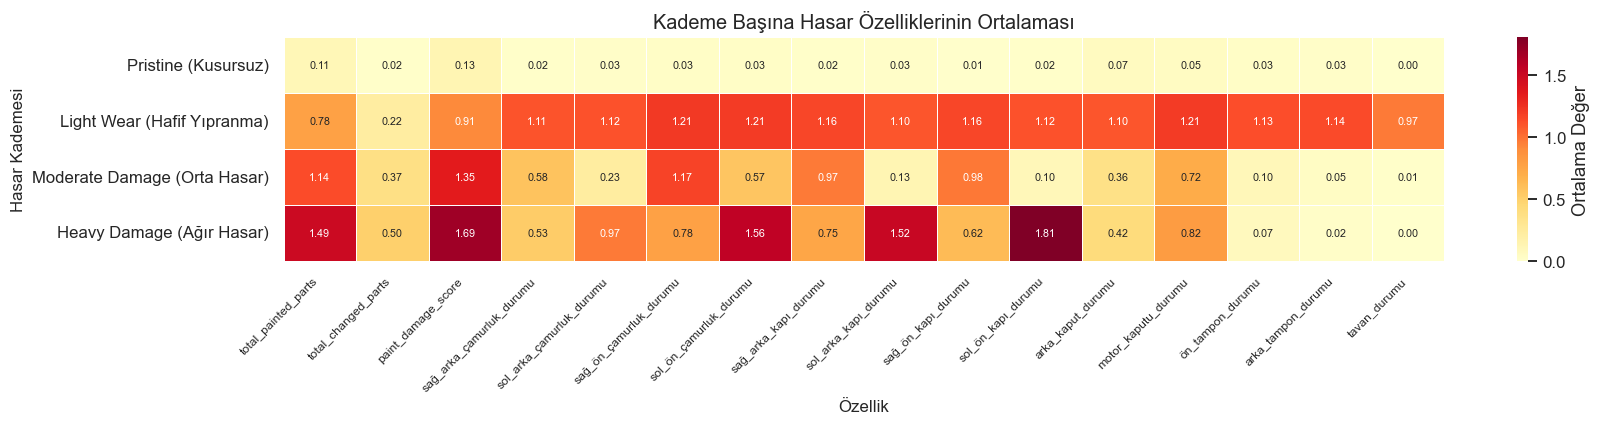

In [26]:
isi_veri = df.groupby('kademe')[damage_cols].mean().reindex(SIRALAMA)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    isi_veri,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Ortalama Değer'},
    annot_kws={'size': 7}
)
ax.set_title('Kademe Başına Hasar Özelliklerinin Ortalaması', fontsize=13)
ax.set_xlabel('Özellik', fontsize=11)
ax.set_ylabel('Hasar Kademesi', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


## Adım 11 (Bonus) — Kutu Grafiği ile Fiyat Dağılımı

Bar grafiğinde yalnızca medyanı görmüştük. Kutu grafiği (boxplot) her kademedeki **dağılımın tamamını** gösterir: medyan, çeyrekler arası aralık (IQR) ve aykırı değerler.


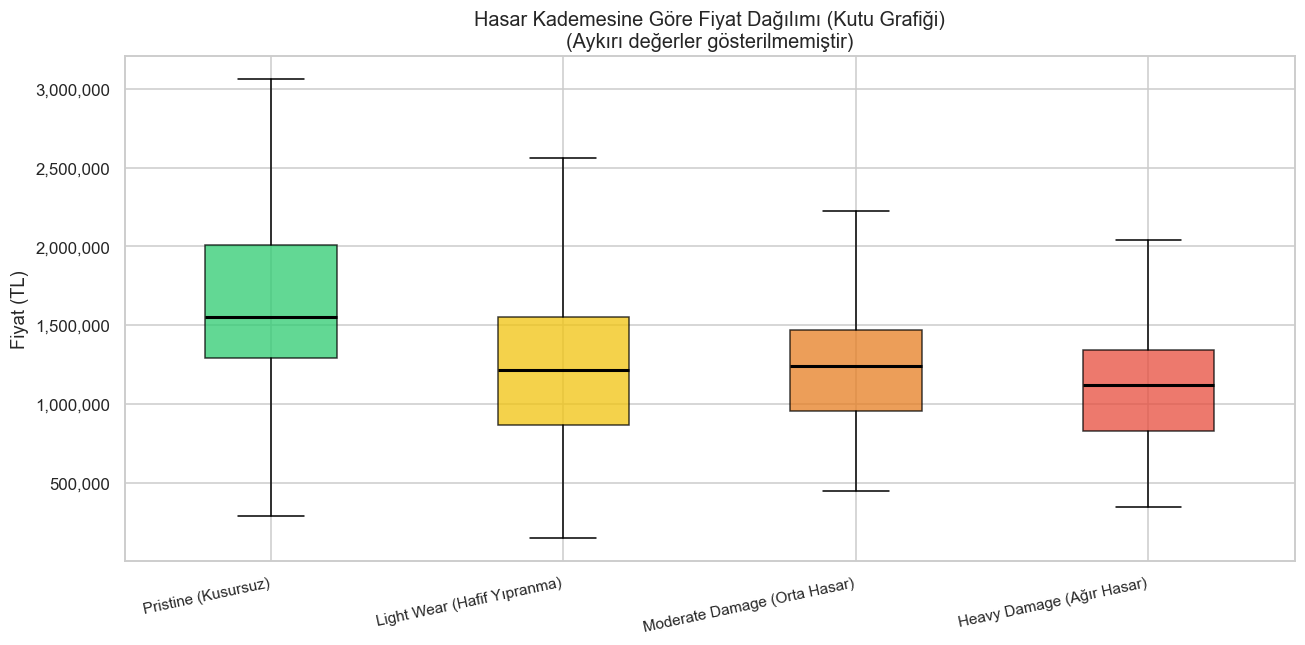

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sıralı kategori ekseni için
df['kademe'] = pd.Categorical(df['kademe'], categories=SIRALAMA, ordered=True)

bp = ax.boxplot(
    [df[df['kademe'] == k]['Fiyat'].dropna() for k in SIRALAMA],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    showfliers=False  # Aykırı değerleri gizle (grafik netliği için)
)

for patch, color in zip(bp['boxes'], RENKLER):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticklabels(SIRALAMA, rotation=12, ha='right', fontsize=10)
ax.set_ylabel('Fiyat (TL)', fontsize=12)
ax.set_title(
    'Hasar Kademesine Göre Fiyat Dağılımı (Kutu Grafiği)\n'
    '(Aykırı değerler gösterilmemiştir)',
    fontsize=13
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


## Sonuç ve Bulgular

### 📌 Kullanılan Yöntemler Özeti

| Adım | Araç / Teknik | Amaç |
|------|--------------|------|
| Veri Hazırlama | `fillna(0)` + `StandardScaler` | Eksik değer ve ölçek sorununun giderilmesi |
| Optimal k | Elbow + Silhouette | Küme sayısının bilimsel olarak belirlenmesi |
| Kümeleme | `KMeans(k=4, n_init=10)` | Gözetimsiz sınıflandırma |
| Etiketleme | Hasar skoru ortalama sıralaması | Kümelere anlamlı isim verilmesi |
| Görselleştirme | PCA (2D) + Boxplot + Heatmap | Çok boyutlu yapının incelenmesi |
| Doğrulama | Silhouette Skoru + Orijinallik Oranı | Küme kalitesinin ölçülmesi |

### 🔑 Temel Bulgular

1. **4 farklı hasar kademesi** veri tarafından desteklenmektedir: Kusursuz → Hafif → Orta → Ağır
2. **Hasar-Fiyat ilişkisi monoton:** Hasar arttıkça medyan fiyat düşmektedir
3. **Değer kaybı oranları** Pristine baz alınarak hesaplanmıştır (bkz. Adım 7)
4. **Doğrulama başarılı:** Pristine kümesinde orijinal araç oranı en yüksek
5. **Silhouette Skoru ≈ 0.50+** — Kümeler anlamlı biçimde ayrışmıştır

### 💡 Gerçek Dünya Uygulaması

Bu model bir alıcıya/satıcıya şunu söyler:  
> *"Bu araç Moderate Damage kümesine ait; benzer araçların medyan değeri Pristine'e göre X% daha düşüktür."*

Hasar kademesi, bağımsız bir **fiyatlama sinyali** olarak kullanılabilir; regresyon modellerine girdi özelliği olarak eklenebilir.


In [28]:
# ── Nihai Özet Çıktı ────────────────────────────────────────────────────────
print("=" * 65)
print("  MODEL 3 — NİHAİ SONUÇLAR")
print("=" * 65)
print()
print(fiyat_ozet.to_string(index=False))
print()
print("-" * 65)
print(f"  Silhouette Skoru  : {final_sil:.4f}")
print(f"  Toplam Araç       : {len(df)}")
print(f"  Küme Sayısı       : 4")
print(f"  Algoritma         : K-Means (n_init=10, random_state=42)")
print("=" * 65)


  MODEL 3 — NİHAİ SONUÇLAR

                      Kademe  Medyan_Fiyat  Deger_Kaybi_%
         Pristine (Kusursuz)     1550000.0            0.0
 Light Wear (Hafif Yıpranma)     1215000.0          -21.6
Moderate Damage (Orta Hasar)     1240000.0          -20.0
   Heavy Damage (Ağır Hasar)     1119000.0          -27.8

-----------------------------------------------------------------
  Silhouette Skoru  : 0.5436
  Toplam Araç       : 2589
  Küme Sayısı       : 4
  Algoritma         : K-Means (n_init=10, random_state=42)
